# RuO2 k-slice: Diagonal Cut of the Tetragonal Brillouin Zone

This notebook analyzes a 2D slice through the Brillouin zone defined by:

- **kslice_corner:** `(-0.5, -0.5, -0.5)` (Gamma point)
- **kslice_b1:** `(0.5, 0.5, -0.5)` (direction to M point)
- **kslice_b2:** `(-0.5, -0.5, 0.5)` (direction to A point via Z)
- **kslice_2dkmesh:** `200 x 200` (2D k-mesh for the slice)

This corresponds to a diagonal cut in the tetragonal Brillouin zone.

# Read and Plot RuO2 k-slice Curvature Components
This notebook reads coordinate and curvature data, then plots each curvature component as a heatmap.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read coordinates
coords = np.loadtxt('down/RuO2-kslice-coord.dat')
kx, ky = coords[:,0], coords[:,1]

In [7]:
# Read curvature data (all components)
curvup = np.loadtxt('up/RuO2-kslice-curv.dat')
curvdown = np.loadtxt('down/RuO2-kslice-curv.dat')
curv = curvup + curvdown
n_components = curv.shape[1] if curv.ndim > 1 else 1
print(f'Number of components: {n_components}')
print(f'maximum curvature up: {np.max(curvup)}')
print(f'maximum curvature down: {np.max(curvdown)}')
print(f'maximum curvature total: {np.max(curv)}')

Number of components: 3
maximum curvature up: 0.16958068
maximum curvature down: 0.10347847
maximum curvature total: 0.258696314


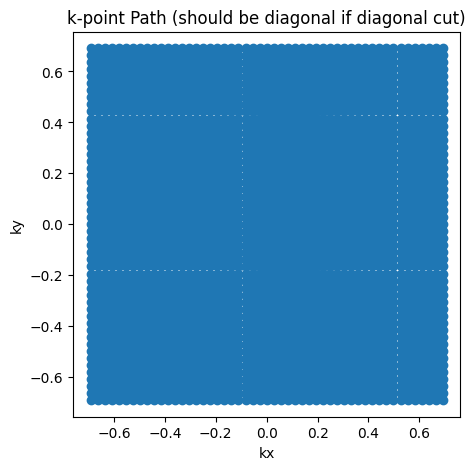

In [8]:
# Visualize the k-point path to check if it's a diagonal cut
plt.figure(figsize=(5,5))
plt.plot(kx, ky, marker='o')
plt.xlabel('kx')
plt.ylabel('ky')
plt.title('k-point Path (should be diagonal if diagonal cut)')
plt.axis('equal')
plt.show()

In [5]:
# Print min/max for kx and ky to inspect the path numerically
print(f'kx: min={kx.min()}, max={kx.max()}')
print(f'ky: min={ky.min()}, max={ky.max()}')

kx: min=-0.69190456, max=0.69190456
ky: min=-0.69190456, max=0.69190456


Grid shape: (51, 51)


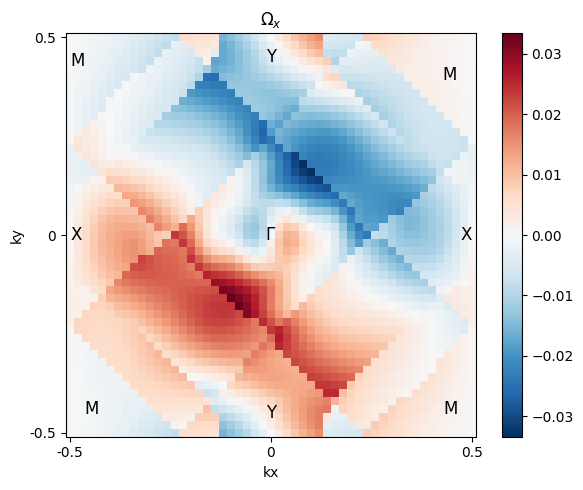

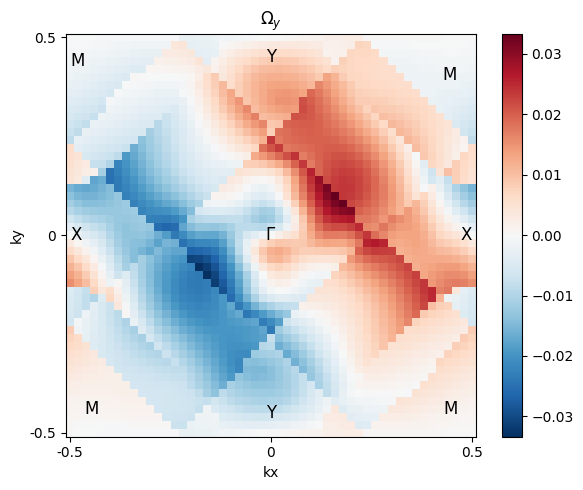

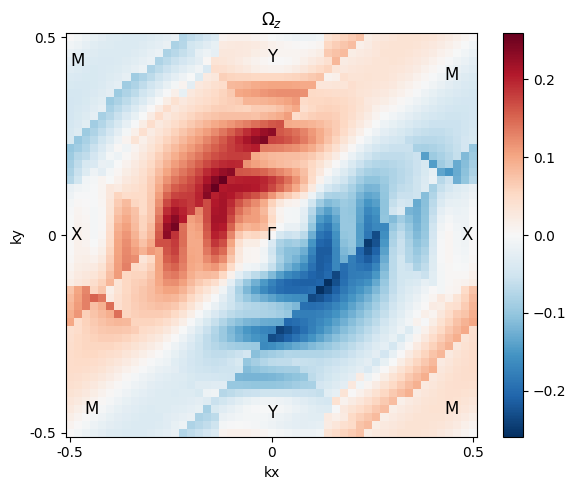

In [9]:
# Plot each component as a heatmap
from math import sqrt

# Try to infer grid shape (assume square or rectangular grid)
n_points = len(kx)
grid_shape = None
for n in range(1, int(sqrt(n_points))+2):
    if n_points % n == 0:
        m = n_points // n
        if np.unique(kx).size == n or np.unique(ky).size == m:
            grid_shape = (n, m)
            break
if grid_shape is None:
    grid_shape = (np.unique(kx).size, np.unique(ky).size)

print(f'Grid shape: {grid_shape}')

kx_grid = kx.reshape(grid_shape)
ky_grid = ky.reshape(grid_shape)
label = ['x', 'y', 'z']
b = 0.69190456
for i in range(n_components):
    plt.figure(figsize=(6,5))
    data = curv[:,i] if n_components > 1 else curv
    data_grid = data.reshape(grid_shape)
    plt.pcolormesh(kx_grid, ky_grid, data_grid, shading='auto', cmap='RdBu_r')
    plt.colorbar()
    plt.xlabel('kx')
    plt.ylabel('ky')
    plt.xticks([-b, 0, b], ["-0.5", "0", "0.5"])
    plt.yticks([-b, 0, b], ["-0.5", "0", "0.5"])
    plt.text(0.,0., r'$\Gamma$', fontsize=12, ha='center', va='center', color='black')
    plt.text(b,0.,       r'X', fontsize=12, ha='right', va='center', color='black')
    plt.text(0.,b - 0.1, r'Y', fontsize=12, ha='center', va='bottom', color='black')
    plt.text(-b,0., r'X', fontsize=12, ha='left', va='center', color='black')
    plt.text(0.,-b +0.1, r'Y', fontsize=12, ha='center', va='top', color='black')
    plt.text(b - 0.1,b - 0.1,   r'M', fontsize=12, ha='left', va='top', color='black')
    plt.text(b - 0.05,-b +0.05,   r'M', fontsize=12, ha='right', va='bottom', color='black')
    plt.text(-b +0.05,b - 0.05, r'M', fontsize=12, ha='right', va='top', color='black')
    plt.text(-b + 0.05,-b +0.05,r'M', fontsize=12, ha='left', va='bottom', color='black')
    plt.title(fr'$\Omega_{{{label[i]}}}$')
    plt.tight_layout()
    plt.show()
